# 04 — Synthetic Stress

**Benchmark:** Benchmark 3 — Synthetic Stress Benchmark  
**Scope:** Synthetic stress scenarios: `100M` real-like scale, `10M_skewed`, and `10M_highuid`.  
**Frameworks:** Pandas, Polars eager, Polars lazy, Dask.

**Claim supported by this notebook:** This notebook evaluates framework robustness under synthetic stress conditions and identifies scale, skew, cardinality, and failure-mode behavior that is not visible in normal real-data row scaling.

Notebook này không chạy benchmark workload. Notebook chỉ đọc kết quả đã có trong `results/raw/` và phân tích robustness của framework dưới các điều kiện synthetic khó: row count rất lớn, key skew mạnh, và ID cardinality cao.

Điểm quan trọng của notebook này là **phân biệt dữ liệu không chạy vì giới hạn tài nguyên** với dữ liệu bị thiếu. Với `100M`, Pandas được loại khỏi phạm vi chạy vì nằm ngoài practical memory envelope của môi trường benchmark hiện tại; Polars eager đã được thử và làm máy shutdown; join ở `100M` cũng quá lớn và làm máy shutdown. Vì vậy phần `100M` chỉ phân tích `filter` và `groupby` cho Polars lazy và Dask.

## 1. Research Questions

Notebook này trả lời sáu câu hỏi chính:

1. Ở synthetic `100M` real-like, Polars lazy và Dask xử lý `filter`/`groupby` tốt đến mức nào?
2. Kết quả `100M` này nằm ở đâu nếu đặt cạnh mốc real data `1M`, `10M`, `50M` của cùng framework?
3. Với `10M_skewed`, framework nào nhạy nhất với key skew?
4. Với `10M_highuid`, framework nào bị ảnh hưởng nhiều nhất bởi cardinality cao?
5. Stress synthetic làm runtime và memory thay đổi bao nhiêu so với mốc real `10M` trong cùng framework/workload?
6. Các giới hạn tài nguyên quan sát được nói gì về phạm vi dùng thực tế của Pandas, Polars eager, Polars lazy và Dask?

## 2. Comparison Boundary

Notebook này chỉ hỗ trợ các so sánh sau. Bảng này được lưu ra CSV ở cuối notebook để final report có thể reuse trực tiếp.

In [1]:
import pandas as pd

comparison_boundary = pd.DataFrame([
    {
        "comparison": "10M_skewed vs real_10M",
        "validity": "valid",
        "reason": "Same framework, same workload, same 10M row-count baseline; measures skew sensitivity.",
    },
    {
        "comparison": "10M_highuid vs real_10M",
        "validity": "valid",
        "reason": "Same framework, same workload, same 10M row-count baseline; measures high-cardinality sensitivity.",
    },
    {
        "comparison": "Polars lazy vs Dask at 100M filter/groupby",
        "validity": "valid",
        "reason": "This is the reportable scope of the 100M stress-scale probe.",
    },
    {
        "comparison": "100M synthetic vs real 50M as a scaling law",
        "validity": "invalid",
        "reason": "Different dataset source and physical footprint; use only as a visual reference marker.",
    },
    {
        "comparison": "Pandas is worse at 100M",
        "validity": "invalid",
        "reason": "Pandas 100M was excluded, not successfully benchmarked.",
    },
    {
        "comparison": "Infer 100M join/pipeline behavior from filter/groupby",
        "validity": "invalid",
        "reason": "Join and pipeline have different intermediate/output pressure and are outside the safe 100M scope.",
    },
])

display(comparison_boundary)

,comparison,validity,reason
0,10M_skewed vs real_10M,valid,"Same framework, same workload, same 10M row-co..."
1,10M_highuid vs real_10M,valid,"Same framework, same workload, same 10M row-co..."
2,Polars lazy vs Dask at 100M filter/groupby,valid,This is the reportable scope of the 100M stres...
3,100M synthetic vs real 50M as a scaling law,invalid,Different dataset source and physical footprin...
4,Pandas is worse at 100M,invalid,"Pandas 100M was excluded, not successfully ben..."
5,Infer 100M join/pipeline behavior from filter/...,invalid,Join and pipeline have different intermediate/...


## 3. Synthetic Validation Dependency

Các synthetic profile trong notebook này (`real_like_100m`, `heavy_skew_10m`, `high_unique_id_10m`) phải được validate trước trong [01c_validate_synthetic.ipynb](</D:/Polar vs Dask/notebooks/data_prep/01c_validate_synthetic.ipynb>).

Nếu validation chưa pass, kết luận trong notebook này chỉ nên đọc là exploratory stress observations, không phải report-level benchmark claims.

In [2]:
import pandas as pd

synthetic_validation_requirements = pd.DataFrame([
    {"requirement": "schema compatibility", "reason": "Stress results must use comparable columns and dtypes."},
    {"requirement": "row count", "reason": "Scenario labels such as 10M and 100M must match generated data."},
    {"requirement": "key cardinality", "reason": "High-cardinality stress must be intentional and measured."},
    {"requirement": "key skew / frequency behavior", "reason": "Heavy-skew stress must show stronger skew than baseline data."},
    {"requirement": "text length distribution", "reason": "String memory footprint affects runtime and peak RSS."},
    {"requirement": "rating distribution", "reason": "Filter selectivity depends on value distribution."},
    {"requirement": "null ratio", "reason": "Null handling can affect physical and execution behavior."},
    {"requirement": "memory footprint", "reason": "Stress interpretation depends on practical memory pressure."},
])

display(synthetic_validation_requirements)

,requirement,reason
0,schema compatibility,Stress results must use comparable columns and...
1,row count,Scenario labels such as 10M and 100M must matc...
2,key cardinality,High-cardinality stress must be intentional an...
3,key skew / frequency behavior,Heavy-skew stress must show stronger skew than...
4,text length distribution,String memory footprint affects runtime and pe...
5,rating distribution,Filter selectivity depends on value distribution.
6,null ratio,Null handling can affect physical and executio...
7,memory footprint,Stress interpretation depends on practical mem...


### Synthetic Validation Dependency

Synthetic stress benchmark chỉ có thể được diễn giải đúng nếu các synthetic dataset đã thỏa mãn những yêu cầu validation tương ứng. Bảng dưới đây tóm tắt các kiểm tra cần có và lý do vì sao mỗi kiểm tra quan trọng.

| Requirement | Applies to | Validation signal | Reason |
|---|---|---|---|
| Schema compatibility | Tất cả synthetic profiles | Columns và dtypes khớp với schema của real benchmark | Stress results phải dùng các cột và kiểu dữ liệu có thể so sánh được giữa các framework. |
| Row count | Tất cả synthetic profiles | Số dòng thực tế khớp với scenario label như `10M` hoặc `100M` | Scenario label phải phản ánh đúng scale đang được benchmark. |
| Key cardinality | `high_unique_id_10M` | Unique count và uniqueness ratio cao hơn real-data baseline một cách có chủ đích | High-cardinality stress phải là đặc tính được thiết kế có chủ ý, không phải sai lệch ngẫu nhiên. |
| Key skew / frequency behavior | `heavy_skew_10M` | Top-k key frequency, Gini coefficient, hoặc Zipf-like skew mạnh hơn real-data baseline | Heavy-skew stress phải thể hiện mức skew mạnh hơn dữ liệu real thông thường. |
| Text length distribution | `real_like_100M`, và các profile có text columns ảnh hưởng đến workload cost | Text length p50, p90, p99 gần với profile mong muốn | Độ dài text ảnh hưởng trực tiếp đến memory footprint, runtime, và chi phí parquet decoding. |
| Rating distribution | Các profile có filter workloads | Tỷ lệ các rating category khớp với distribution mong muốn | Filter selectivity phụ thuộc vào phân phối giá trị. |
| Null ratio | Tất cả synthetic profiles | Tỷ lệ null theo từng cột quan trọng gần với profile mong muốn | Null handling có thể ảnh hưởng đến physical size, memory usage, và execution behavior. |
| Memory footprint | Tất cả synthetic profiles | Estimated bytes per row và total memory footprint nằm trong phạm vi kỳ vọng | Diễn giải stress benchmark phụ thuộc vào memory pressure thực tế, không chỉ phụ thuộc vào row count. |

Các kiểm tra này nên được xác nhận trong synthetic validation notebook trước khi diễn giải kết quả synthetic stress benchmark. Nếu một synthetic profile chưa pass validation, kết luận từ notebook này chỉ nên được xem là exploratory thay vì final.

## 4. Setup and Data Loading

Code dùng key và tên biến tiếng Anh để khớp với CSV benchmark. Nội dung markdown dùng tiếng Việt để giải thích kết quả.

In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() in {"benchmark", "benchmarks", "analysis", "report", "data_prep"}:
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.resolve()
elif PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

RESULTS_DIR = PROJECT_ROOT / "results" / "raw"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "notebook_04_synthetic_stress"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

STRESS_FILES = [
    RESULTS_DIR / "dask_100m_results.csv",
    RESULTS_DIR / "polars_100m_results.csv",
    RESULTS_DIR / "dask_highuid_skewed_results.csv",
    RESULTS_DIR / "pandas_highuid_skewed_results.csv",
    RESULTS_DIR / "polars_highuid_skewed_results.csv",
    RESULTS_DIR / "polars_eager_highuid_skewed_results.csv",
]

REAL_BASELINE_FILES = [
    RESULTS_DIR / "dask_real_results.csv",
    RESULTS_DIR / "pandas_real_results.csv",
    RESULTS_DIR / "polars_real_results.csv",
    RESULTS_DIR / "polars_eager_real_results.csv",
]

FRAMEWORK_ORDER = ["pandas", "polars_eager", "polars_lazy", "dask"]
WORKLOAD_ORDER = ["filter", "groupby", "join", "pipeline"]
ROW_ORDER = ["1M", "10M", "50M", "100M"]
STRESS_ORDER = ["10M_skewed", "10M_highuid"]
FRAMEWORK_LABELS = {
    "pandas": "Pandas",
    "polars_eager": "Polars eager",
    "polars_lazy": "Polars lazy",
    "dask": "Dask",
}

In [4]:
available_files = [path for path in STRESS_FILES + REAL_BASELINE_FILES if path.exists()]
missing_files = [path.name for path in STRESS_FILES + REAL_BASELINE_FILES if not path.exists()]

if missing_files:
    print("Missing files:", missing_files)

if not available_files:
    raise FileNotFoundError("No benchmark CSV files were found in results/raw/.")

frames = []
for path in available_files:
    frame = pd.read_csv(path)
    frame["source_file"] = path.name
    if "100m" in path.name.lower() or "highuid_skewed" in path.name.lower():
        frame["benchmark_family"] = "synthetic_stress"
    elif "real" in path.name.lower():
        frame["benchmark_family"] = "real_baseline"
    else:
        frame["benchmark_family"] = "other"
    frames.append(frame)

df_raw = pd.concat(frames, ignore_index=True)

required_columns = {
    "timestamp", "framework", "workload", "dataset_size", "n_rows",
    "run_index", "time_s", "peak_memory_mb", "throughput_rows_per_s", "status", "notes"
}
missing_columns = sorted(required_columns - set(df_raw.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

for col in ["time_s", "peak_memory_mb", "throughput_rows_per_s", "n_rows"]:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

df_raw["framework"] = pd.Categorical(df_raw["framework"], FRAMEWORK_ORDER, ordered=True)
df_raw["workload"] = pd.Categorical(df_raw["workload"], WORKLOAD_ORDER, ordered=True)
df_raw["dataset_size"] = df_raw["dataset_size"].astype(str)

def scenario_label(dataset_size):
    if dataset_size == "100M":
        return "100M_real_like"
    if dataset_size == "10M_skewed":
        return "heavy_skew_10M"
    if dataset_size == "10M_highuid":
        return "high_unique_id_10M"
    return "real_baseline"

df_raw["stress_scenario"] = df_raw["dataset_size"].map(scenario_label)

display(df_raw.head())
print(f"Loaded rows: {len(df_raw):,}")
print(f"Sources: {', '.join(sorted(df_raw['source_file'].unique()))}")

,timestamp,framework,workload,dataset_size,n_rows,run_index,time_s,peak_memory_mb,throughput_rows_per_s,status,notes,source_file,benchmark_family,stress_scenario
0,2026-05-09T20:07:27,dask,filter,100M,100000000,1,109.2020,11697.36,915734,ok,partition_size=128MB,dask_100m_results.csv,synthetic_stress,100M_real_like
1,2026-05-09T20:09:20,dask,filter,100M,100000000,2,111.9280,10817.42,893431,ok,partition_size=128MB,dask_100m_results.csv,synthetic_stress,100M_real_like
2,2026-05-09T20:11:15,dask,filter,100M,100000000,3,114.6295,11884.82,872375,ok,partition_size=128MB,dask_100m_results.csv,synthetic_stress,100M_real_like
3,2026-05-09T20:11:49,dask,groupby,100M,100000000,1,16.8061,6599.91,5950221,ok,partition_size=128MB,dask_100m_results.csv,synthetic_stress,100M_real_like
4,2026-05-09T20:12:06,dask,groupby,100M,100000000,2,17.2308,6112.52,5803551,ok,partition_size=128MB,dask_100m_results.csv,synthetic_stress,100M_real_like


Loaded rows: 252
Sources: dask_100m_results.csv, dask_highuid_skewed_results.csv, dask_real_results.csv, pandas_highuid_skewed_results.csv, pandas_real_results.csv, polars_100m_results.csv, polars_eager_highuid_skewed_results.csv, polars_eager_real_results.csv, polars_highuid_skewed_results.csv, polars_real_results.csv


## 5. Data Completeness Check

Phân tích runtime/memory chính chỉ dùng `status == "ok"`. Những trường hợp không có kết quả ở `100M` được ghi riêng vì đây là giới hạn thực nghiệm đã quan sát được, không phải lỗi load dữ liệu.

In [5]:
df_ok = df_raw[df_raw["status"] == "ok"].copy()
df_fail = df_raw[df_raw["status"] != "ok"].copy()

run_count = (
    df_raw
    .groupby(["benchmark_family", "framework", "dataset_size", "workload", "status"], observed=True)
    .size()
    .rename("n_runs")
    .reset_index()
    .sort_values(["benchmark_family", "dataset_size", "framework", "workload"])
)

display(run_count)
print(f"Successful rows: {len(df_ok):,}")
print(f"Failed rows    : {len(df_fail):,}")

,benchmark_family,framework,dataset_size,workload,status,n_runs
0,real_baseline,pandas,10M,filter,ok,3
1,real_baseline,pandas,10M,groupby,ok,3
2,real_baseline,pandas,10M,join,ok,3
3,real_baseline,pandas,10M,pipeline,ok,3
12,real_baseline,polars_eager,10M,filter,ok,3
...,...,...,...,...,...,...
73,synthetic_stress,polars_lazy,10M_skewed,pipeline,ok,3
80,synthetic_stress,dask,10M_skewed,filter,ok,3
81,synthetic_stress,dask,10M_skewed,groupby,ok,3
82,synthetic_stress,dask,10M_skewed,join,ok,3


Successful rows: 252
Failed rows    : 0


In [6]:
stress_completion = (
    df_ok[df_ok["benchmark_family"] == "synthetic_stress"]
    .groupby(["dataset_size", "framework", "workload"], observed=True)["run_index"]
    .count()
    .rename("successful_runs")
    .reset_index()
    .pivot_table(
        index=["dataset_size", "framework"],
        columns="workload",
        values="successful_runs",
        fill_value=0,
        observed=True,
    )
)

display(stress_completion)

workload                   filter  groupby  join  pipeline
dataset_size framework                                    
100M         polars_lazy      3.0      3.0   0.0       0.0
             dask             3.0      3.0   0.0       0.0
10M_highuid  pandas           3.0      3.0   3.0       3.0
             polars_eager     3.0      3.0   3.0       3.0
             polars_lazy      3.0      3.0   3.0       3.0
             dask             3.0      3.0   3.0       3.0
10M_skewed   pandas           3.0      3.0   3.0       3.0
             polars_eager     3.0      3.0   3.0       3.0
             polars_lazy      3.0      3.0   3.0       3.0
             dask             3.0      3.0   3.0       3.0

### Methodological Boundary

Scenario `100M` không nên được diễn giải như một benchmark matrix đầy đủ. Đây là một stress-scale probe có chủ đích, dùng để kiểm tra liệu synthetic data ở scale lớn hơn có thể được xử lý trong benchmark environment hiện tại hay không.

Đối với scenario `100M`:

- Pandas `100M` bị excluded vì nằm ngoài practical memory envelope của benchmark environment hiện tại.
- Polars eager `100M` đã được thử, nhưng gây machine shutdown. Trường hợp này nên được ghi nhận là environment-specific abort, không phải kết luận tổng quát rằng Polars eager không bao giờ xử lý được `100M` rows.
- `100M` join bị excluded khỏi reportable benchmark matrix vì join output hoặc intermediate state quá lớn và trước đó đã gây shutdown behavior.
- `100M` pipeline được omitted by design vì pipeline workload có thể tái tạo intermediate memory pressure tương tự join.

Vì vậy, reportable `100M` matrix chỉ gồm:

| Dataset size | Frameworks | Workloads |
|---|---|---|
| `100M` | `polars_lazy`, `dask` | `filter`, `groupby` |

Các stress scenario `10M_skewed` và `10M_highuid` là full stress matrices. Chúng bao gồm Pandas, Polars eager, Polars lazy, và Dask cho đủ bốn workload: `filter`, `groupby`, `join`, và `pipeline`.

| Dataset size | Frameworks | Workloads |
|---|---|---|
| `10M_skewed` | `pandas`, `polars_eager`, `polars_lazy`, `dask` | `filter`, `groupby`, `join`, `pipeline` |
| `10M_highuid` | `pandas`, `polars_eager`, `polars_lazy`, `dask` | `filter`, `groupby`, `join`, `pipeline` |

Quan trọng: các case omitted-by-design không nên được tính là actual framework failures khi ranking robustness. Actual failures chỉ nên bao gồm những run đã được thực thi và trả về `failed`, `timeout`, `OOM`, `error`, hoặc gây documented shutdown/abort.

In [7]:
omitted_100m = pd.DataFrame([
    {
        "scenario": "100M_real_like",
        "framework": "pandas",
        "workload": "filter/groupby/join/pipeline",
        "scope_status": "omitted_by_design",
        "failure_class": "practical_memory_envelope",
        "reason": "Pandas 100M was excluded because it is outside the practical memory envelope of the current benchmark environment.",
    },
    {
        "scenario": "100M_real_like",
        "framework": "polars_eager",
        "workload": "filter/groupby/join/pipeline",
        "scope_status": "attempted_aborted",
        "failure_class": "system_shutdown",
        "reason": "Polars eager 100M was attempted and caused the machine to shut down; it is excluded from the reportable 100M matrix.",
    },
    {
        "scenario": "100M_real_like",
        "framework": "polars_lazy/dask",
        "workload": "join",
        "scope_status": "attempted_aborted",
        "failure_class": "system_shutdown",
        "reason": "100M join materialization/intermediate size was too large and caused shutdown.",
    },
    {
        "scenario": "100M_real_like",
        "framework": "polars_lazy/dask",
        "workload": "pipeline",
        "scope_status": "omitted_by_design",
        "failure_class": "out_of_scope_due_to_join_pressure",
        "reason": "Pipeline is excluded from 100M stress interpretation because join-like intermediate pressure is too risky for this environment.",
    },
])

display(omitted_100m)

,scenario,framework,workload,scope_status,failure_class,reason
0,100M_real_like,pandas,filter/groupby/join/pipeline,omitted_by_design,practical_memory_envelope,Pandas 100M was excluded because it is outside...
1,100M_real_like,polars_eager,filter/groupby/join/pipeline,attempted_aborted,system_shutdown,Polars eager 100M was attempted and caused the...
2,100M_real_like,polars_lazy/dask,join,attempted_aborted,system_shutdown,100M join materialization/intermediate size wa...
3,100M_real_like,polars_lazy/dask,pipeline,omitted_by_design,out_of_scope_due_to_join_pressure,Pipeline is excluded from 100M stress interpre...


## 4. Summary Table

Bảng `summary` là nguồn chính cho các phân tích tiếp theo. Mỗi tổ hợp dùng mean, standard deviation và số run thành công.

In [8]:
summary = (
    df_ok
    .groupby(["benchmark_family", "stress_scenario", "dataset_size", "framework", "workload"], observed=True)
    .agg(
        n_rows=("n_rows", "median"),
        n_runs=("run_index", "count"),
        time_mean_s=("time_s", "mean"),
        time_std_s=("time_s", "std"),
        memory_mean_mb=("peak_memory_mb", "mean"),
        memory_std_mb=("peak_memory_mb", "std"),
        throughput_mean_rows_s=("throughput_rows_per_s", "mean"),
        throughput_std_rows_s=("throughput_rows_per_s", "std"),
    )
    .reset_index()
)

summary["time_cv"] = summary["time_std_s"] / summary["time_mean_s"]
summary["memory_gb"] = summary["memory_mean_mb"] / 1024
summary["rows_per_second_m"] = summary["throughput_mean_rows_s"] / 1_000_000
summary["seconds_per_million_rows"] = summary["time_mean_s"] / (summary["n_rows"] / 1_000_000)

summary_display = summary.copy()
for col in ["time_mean_s", "time_std_s", "memory_mean_mb", "memory_std_mb", "time_cv", "memory_gb", "rows_per_second_m", "seconds_per_million_rows"]:
    summary_display[col] = summary_display[col].round(3)

display(summary_display.sort_values(["benchmark_family", "dataset_size", "workload", "framework"]))

,benchmark_family,stress_scenario,dataset_size,framework,workload,n_rows,n_runs,time_mean_s,time_std_s,memory_mean_mb,memory_std_mb,throughput_mean_rows_s,throughput_std_rows_s,time_cv,memory_gb,rows_per_second_m,seconds_per_million_rows
0,real_baseline,real_baseline,10M,pandas,filter,10000000.0,3,31.514,3.656,6576.447,13.882,3.204027e+05,39822.497377,0.116,6.422,0.320,3.151
4,real_baseline,real_baseline,10M,polars_eager,filter,10000000.0,3,1.793,0.075,4423.837,109.256,5.584166e+06,227493.065130,0.042,4.320,5.584,0.179
8,real_baseline,real_baseline,10M,polars_lazy,filter,10000000.0,3,3.633,0.149,3398.587,17.769,2.755600e+06,111115.610888,0.041,3.319,2.756,0.363
12,real_baseline,real_baseline,10M,dask,filter,10000000.0,3,6.198,0.171,6401.857,201.703,1.614246e+06,44839.889875,0.028,6.252,1.614,0.620
1,real_baseline,real_baseline,10M,pandas,groupby,10000000.0,3,27.275,4.653,6374.743,58.029,3.732333e+05,57995.502535,0.171,6.225,0.373,2.727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,synthetic_stress,heavy_skew_10M,10M_skewed,dask,join,10000000.0,3,24.552,2.480,10768.413,1173.627,4.099570e+05,39411.738492,0.101,10.516,0.410,2.455
55,synthetic_stress,heavy_skew_10M,10M_skewed,pandas,pipeline,10000000.0,3,20.558,0.072,7004.877,28.654,4.864310e+05,1700.860077,0.004,6.841,0.486,2.056
59,synthetic_stress,heavy_skew_10M,10M_skewed,polars_eager,pipeline,10000000.0,3,4.381,0.464,5822.367,64.228,2.299033e+06,230716.303378,0.106,5.686,2.299,0.438
63,synthetic_stress,heavy_skew_10M,10M_skewed,polars_lazy,pipeline,10000000.0,3,5.106,0.666,2247.260,42.770,1.981694e+06,268379.542758,0.130,2.195,1.982,0.511


## 5. `100M` Real-like Stress Scale

Phần này chỉ so sánh Polars lazy và Dask trên `filter` và `groupby`. Đây là câu hỏi về khả năng đi qua scale rất lớn trong điều kiện còn an toàn cho máy, không phải benchmark đầy đủ mọi workload.

In [9]:
stress_100m = summary[
    (summary["benchmark_family"] == "synthetic_stress")
    & (summary["dataset_size"] == "100M")
    & (summary["workload"].isin(["filter", "groupby"]))
].copy()

stress_100m_display = stress_100m[[
    "framework", "workload", "n_runs", "time_mean_s", "time_std_s",
    "memory_gb", "rows_per_second_m", "seconds_per_million_rows"
]].copy()
for col in ["time_mean_s", "time_std_s", "memory_gb", "rows_per_second_m", "seconds_per_million_rows"]:
    stress_100m_display[col] = stress_100m_display[col].round(3)

display(stress_100m_display.sort_values(["workload", "framework"]))

,framework,workload,n_runs,time_mean_s,time_std_s,memory_gb,rows_per_second_m,seconds_per_million_rows
48,polars_lazy,filter,3,81.089,2.073,11.833,1.234,0.811
50,dask,filter,3,111.920,2.714,11.198,0.894,1.119
49,polars_lazy,groupby,3,12.662,0.406,3.457,7.903,0.127
51,dask,groupby,3,17.161,0.326,6.123,5.828,0.172


### Nhận xét

Ở scale `100M_real_like`, **Polars lazy nhanh hơn Dask** trên cả hai workload còn nằm trong phạm vi reportable.

Với workload `filter`, Polars lazy đạt trung bình **81.09s**, trong khi Dask mất **111.92s**. Điều này tương ứng với việc Polars lazy nhanh hơn khoảng **1.38×**. Throughput của Polars lazy cũng cao hơn, đạt **1.234 triệu rows/giây** so với **0.894 triệu rows/giây** của Dask.

Với workload `groupby`, Polars lazy tiếp tục nhanh hơn Dask, với thời gian trung bình **12.66s** so với **17.16s**, tương đương khoảng **1.36×**. Đây cũng là workload cho thấy khác biệt rõ hơn về memory: Polars lazy dùng khoảng **3.46 GB**, trong khi Dask dùng khoảng **6.12 GB**.

Tuy nhiên, kết quả này cần được diễn giải trong phạm vi hẹp. Phần `100M_real_like` **không phải benchmark đầy đủ cho mọi workload**, vì `join` và `pipeline` ở scale này đã bị loại khỏi phạm vi an toàn do áp lực materialization và rủi ro system shutdown. Do đó, kết luận ở đây chỉ nên áp dụng cho khả năng xử lý scale lớn của Polars lazy và Dask trên hai workload `filter` và `groupby`.

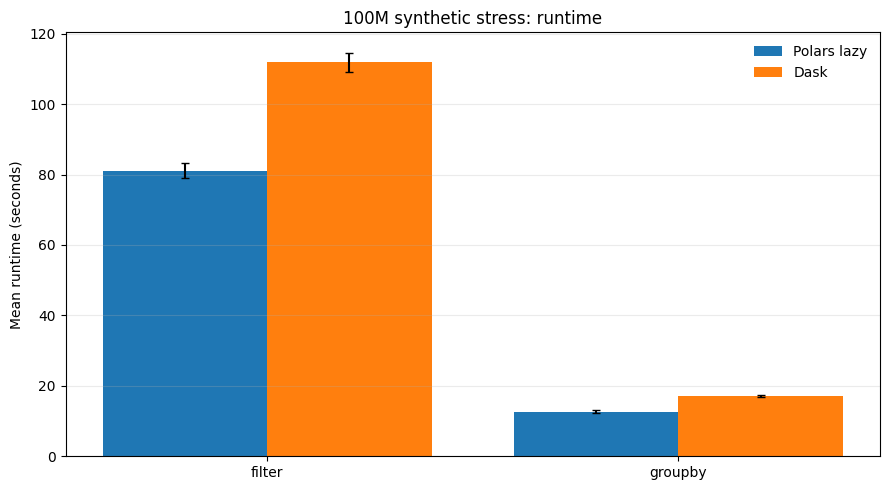

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\100m_runtime.png


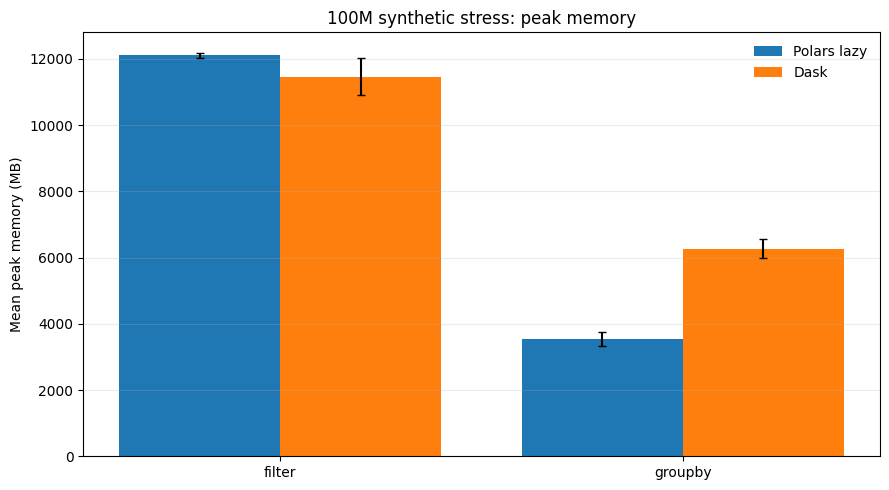

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\100m_memory.png


In [10]:
def grouped_bar(data, x_col, y_col, hue_col, title, ylabel, filename, order=None, hue_order=None):
    plot_data = data.copy()
    if order is None:
        order = list(plot_data[x_col].dropna().unique())
    if hue_order is None:
        hue_order = list(plot_data[hue_col].dropna().unique())

    x = np.arange(len(order))
    width = 0.8 / max(len(hue_order), 1)

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, hue in enumerate(hue_order):
        subset = plot_data[plot_data[hue_col] == hue]
        values = []
        errors = []
        for item in order:
            row = subset[subset[x_col] == item]
            if row.empty:
                values.append(np.nan)
                errors.append(0)
            else:
                values.append(row[y_col].iloc[0])
                err_col = y_col.replace("mean", "std")
                errors.append(row[err_col].iloc[0] if err_col in row.columns else 0)
        ax.bar(x + (i - (len(hue_order) - 1) / 2) * width, values, width, label=FRAMEWORK_LABELS.get(str(hue), str(hue)), yerr=errors, capsize=3)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    out = FIGURE_DIR / filename
    fig.savefig(out, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

grouped_bar(
    stress_100m,
    x_col="workload",
    y_col="time_mean_s",
    hue_col="framework",
    title="100M synthetic stress: runtime",
    ylabel="Mean runtime (seconds)",
    filename="100m_runtime.png",
    order=["filter", "groupby"],
    hue_order=["polars_lazy", "dask"],
)

grouped_bar(
    stress_100m,
    x_col="workload",
    y_col="memory_mean_mb",
    hue_col="framework",
    title="100M synthetic stress: peak memory",
    ylabel="Mean peak memory (MB)",
    filename="100m_memory.png",
    order=["filter", "groupby"],
    hue_order=["polars_lazy", "dask"],
)

### What this means

Ở scale `100M_real_like`, Polars lazy hoàn thành cả hai workload reportable (`filter` và `groupby`) nhanh hơn Dask trong dữ liệu hiện có. Với `filter`, Polars lazy mất khoảng **81.09s**, trong khi Dask mất **111.92s**; với `groupby`, Polars lazy mất khoảng **12.66s**, trong khi Dask mất **17.16s**. Như vậy, Polars lazy nhanh hơn Dask khoảng **1.36–1.38×** trên hai workload này.

Về memory, xu hướng không hoàn toàn giống nhau giữa các workload. Ở `filter`, hai framework đều cần peak memory cao, khoảng **11–12 GB**, vì workload này phải scan và materialize một lượng lớn dữ liệu sau predicate. Dask dùng ít memory hơn một chút trong `filter`, nhưng lại chậm hơn đáng kể về runtime.

Ở `groupby`, khác biệt memory rõ hơn: Polars lazy dùng khoảng **3.46 GB**, thấp hơn nhiều so với **6.12 GB** của Dask. Điều này cho thấy trong workload aggregation ở scale lớn, Polars lazy vừa nhanh hơn vừa tiết kiệm memory hơn trong điều kiện benchmark này.

Tuy nhiên, kết quả `100M_real_like` cần được diễn giải trong phạm vi hẹp. Phần này chỉ chứng minh khả năng xử lý scale lớn trên `filter` và `groupby`; không nên suy diễn sang `join` hoặc `pipeline`, vì các workload đó tạo áp lực materialization/intermediate data lớn hơn và đã bị loại khỏi phạm vi an toàn của benchmark.

## 6. `100M` Compared with Real `1M`/`10M`/`50M`

Phần này đặt `100M` synthetic cạnh mốc real data của cùng framework. Đây không phải so sánh “real vs synthetic” trực tiếp; mục đích là tạo mốc trực quan để thấy `100M` nằm ngoài dải scale real hiện có như thế nào.

In [11]:
real_scale = summary[
    (summary["benchmark_family"] == "real_baseline")
    & (summary["framework"].isin(["polars_lazy", "dask"]))
    & (summary["workload"].isin(["filter", "groupby"]))
    & (summary["dataset_size"].isin(["1M", "10M", "50M"]))
].copy()

scale_compare = pd.concat([real_scale, stress_100m], ignore_index=True)
scale_compare["row_label"] = pd.Categorical(scale_compare["dataset_size"], ROW_ORDER, ordered=True)
scale_compare = scale_compare.sort_values(["workload", "framework", "row_label"])

scale_display = scale_compare[[
    "benchmark_family", "dataset_size", "framework", "workload", "n_rows",
    "time_mean_s", "memory_gb", "rows_per_second_m", "seconds_per_million_rows"
]].copy()
for col in ["time_mean_s", "memory_gb", "rows_per_second_m", "seconds_per_million_rows"]:
    scale_display[col] = scale_display[col].round(3)

display(scale_display)

,benchmark_family,dataset_size,framework,workload,n_rows,time_mean_s,memory_gb,rows_per_second_m,seconds_per_million_rows
4,real_baseline,1M,polars_lazy,filter,1000000.0,0.371,0.672,2.696,0.371
0,real_baseline,10M,polars_lazy,filter,10000000.0,3.633,3.319,2.756,0.363
8,real_baseline,50M,polars_lazy,filter,50000000.0,30.594,12.151,1.636,0.612
12,synthetic_stress,100M,polars_lazy,filter,100000000.0,81.089,11.833,1.234,0.811
6,real_baseline,1M,dask,filter,1000000.0,0.692,0.983,1.446,0.692
2,real_baseline,10M,dask,filter,10000000.0,6.198,6.252,1.614,0.620
10,real_baseline,50M,dask,filter,50000000.0,33.803,10.341,1.489,0.676
14,synthetic_stress,100M,dask,filter,100000000.0,111.920,11.198,0.894,1.119
5,real_baseline,1M,polars_lazy,groupby,1000000.0,0.624,1.386,1.603,0.624
1,real_baseline,10M,polars_lazy,groupby,10000000.0,4.272,4.807,2.343,0.427


### Scaling trend across baseline and stress settings

Bảng này đặt kết quả `100M_real_like` vào cùng trục so sánh với các baseline `1M`, `10M` và `50M`. Vì `100M` thuộc synthetic stress còn các mức nhỏ hơn thuộc real baseline, phần này nên được hiểu như một **scaling perspective**, không phải một so sánh tuyến tính hoàn toàn giữa cùng một dataset.

Đối với workload `filter`, cả Polars lazy và Dask đều cho thấy thời gian xử lý tăng rõ khi kích thước dữ liệu tăng. Polars lazy đi từ **0.371s** ở `1M`, **3.633s** ở `10M`, **30.594s** ở `50M`, đến **81.089s** ở `100M`. Dask cũng tăng từ **0.692s**, **6.198s**, **33.803s**, đến **111.920s**. Điều này cho thấy `filter` chịu áp lực scale khá trực tiếp, đặc biệt khi phải scan và materialize nhiều rows hơn ở kích thước lớn.

Với workload `groupby`, xu hướng không hoàn toàn tuyến tính. Ở `100M_real_like`, cả Polars lazy và Dask có thời gian xử lý tốt hơn kỳ vọng nếu chỉ ngoại suy từ baseline `50M`. Polars lazy giảm từ **18.763s** ở `50M` xuống **12.662s** ở `100M`, còn Dask tăng từ **11.238s** lên **17.161s**. Điều này cho thấy kết quả `groupby` phụ thuộc không chỉ vào số dòng, mà còn vào đặc điểm dữ liệu như cardinality, distribution của key, kích thước output và chi phí aggregation thực tế.

Về memory, `filter` duy trì peak memory cao ở scale lớn, khoảng **11–12 GB** cho cả Polars lazy và Dask ở `100M`. Ngược lại, `groupby` ở `100M` dùng memory thấp hơn nhiều so với `filter`, đặc biệt với Polars lazy (**3.457 GB**). Điều này củng cố nhận xét rằng workload `groupby` trong synthetic stress có output/intermediate footprint nhỏ hơn so với workload `filter`.

Do đó, bảng này cho thấy Polars lazy giữ lợi thế runtime ổn định trước Dask trên `filter`, trong khi ở `groupby`, kết quả chịu ảnh hưởng mạnh hơn bởi cấu trúc dữ liệu và workload shape. Không nên diễn giải `100M` như bước tiếp nối tuyến tính trực tiếp từ `1M–50M`, mà nên xem nó là một stress scenario riêng để kiểm tra khả năng xử lý scale lớn trong phạm vi workload an toàn.

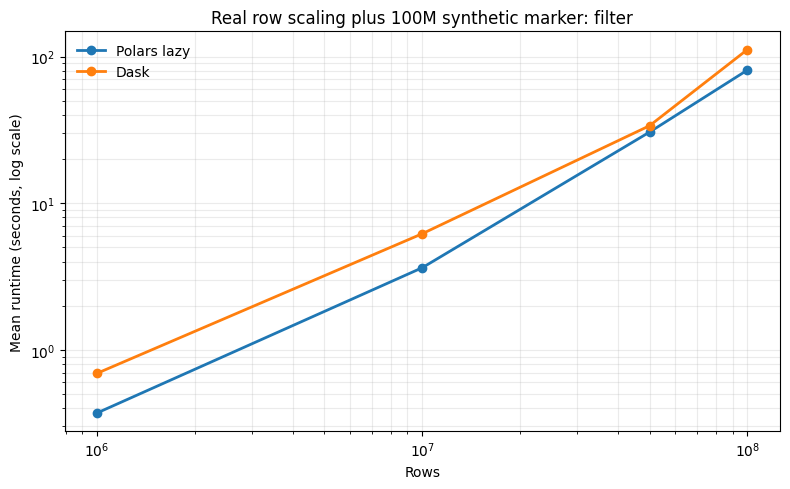

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\real_scale_plus_100m_filter.png


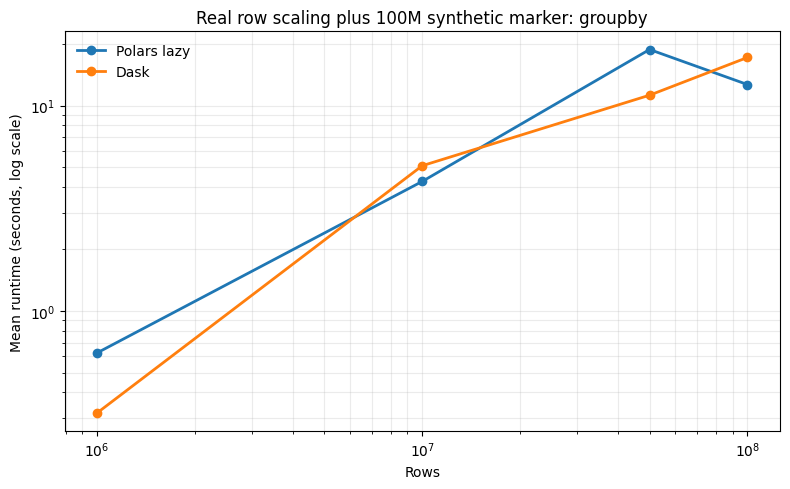

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\real_scale_plus_100m_groupby.png


In [12]:
for workload in ["filter", "groupby"]:
    fig, ax = plt.subplots(figsize=(8, 5))
    subset = scale_compare[scale_compare["workload"] == workload]
    for framework in ["polars_lazy", "dask"]:
        fw = subset[subset["framework"] == framework].sort_values("n_rows")
        ax.plot(
            fw["n_rows"],
            fw["time_mean_s"],
            marker="o",
            linewidth=2,
            label=FRAMEWORK_LABELS.get(framework, framework),
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Real row scaling plus 100M synthetic marker: {workload}")
    ax.set_xlabel("Rows")
    ax.set_ylabel("Mean runtime (seconds, log scale)")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    out = FIGURE_DIR / f"real_scale_plus_100m_{workload}.png"
    fig.savefig(out, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

### Scaling pattern across `filter` and `groupby`

Hai biểu đồ scaling cho thấy `filter` và `groupby` có hành vi rất khác nhau khi số rows tăng từ baseline `1M–50M` đến marker synthetic stress `100M`.

Với workload `filter`, xu hướng scaling khá rõ và ổn định. Runtime của cả Polars lazy và Dask đều tăng khi số rows tăng, phù hợp với bản chất của workload này: chi phí chính đến từ việc scan dữ liệu, áp dụng predicate và materialize phần kết quả sau lọc. Trên toàn bộ các mức dữ liệu, **Polars lazy luôn nhanh hơn Dask**. Ở `1M`, Polars lazy mất **0.371s** so với **0.692s** của Dask; ở `10M`, Polars lazy mất **3.633s** so với **6.198s**; ở `50M`, khoảng cách thu hẹp hơn với **30.594s** so với **33.803s**. Tại marker `100M_real_like`, Polars lazy tiếp tục giữ lợi thế rõ hơn, với **81.089s** so với **111.920s** của Dask.

Ngược lại, workload `groupby` không thể hiện xu hướng tuyến tính đơn giản theo số rows. Ở các baseline `1M`, `10M` và `50M`, Dask có lúc nhanh hơn Polars lazy, đặc biệt tại `1M` và `50M`, trong khi Polars lazy nhỉnh hơn ở `10M`. Tuy nhiên, tại marker `100M_real_like`, xu hướng đổi chiều: Polars lazy đạt **12.662s**, nhanh hơn Dask ở **17.161s**. Điều này cho thấy `groupby` phụ thuộc mạnh vào workload shape, bao gồm cardinality của key, phân phối dữ liệu, kích thước output và chi phí aggregation thực tế, chứ không chỉ phụ thuộc vào tổng số rows.

Vì điểm `100M` thuộc synthetic stress setup, còn các mức `1M–50M` thuộc real baseline, không nên xem `100M` là bước nối tuyến tính hoàn toàn từ `50M`. Thay vào đó, nó nên được hiểu như một **stress marker** để kiểm tra khả năng xử lý scale lớn trong phạm vi workload còn an toàn. Nhìn chung, Polars lazy giữ lợi thế ổn định hơn trên `filter`, còn với `groupby`, kết quả nhạy hơn với cấu trúc dữ liệu nhưng tại synthetic `100M`, Polars lazy xử lý hiệu quả hơn Dask.

In [13]:
# Compare 100M synthetic against 50M real in the same framework/workload.
real_50m = real_scale[real_scale["dataset_size"] == "50M"][["framework", "workload", "time_mean_s", "memory_mean_mb"]]
real_50m = real_50m.rename(columns={"time_mean_s": "real_50m_time_s", "memory_mean_mb": "real_50m_memory_mb"})

compare_100m_vs_50m = stress_100m.merge(real_50m, on=["framework", "workload"], how="left")
compare_100m_vs_50m["time_ratio_vs_real_50m"] = compare_100m_vs_50m["time_mean_s"] / compare_100m_vs_50m["real_50m_time_s"]
compare_100m_vs_50m["memory_ratio_vs_real_50m"] = compare_100m_vs_50m["memory_mean_mb"] / compare_100m_vs_50m["real_50m_memory_mb"]

ratio_display = compare_100m_vs_50m[[
    "framework", "workload", "time_mean_s", "real_50m_time_s", "time_ratio_vs_real_50m",
    "memory_gb", "real_50m_memory_mb", "memory_ratio_vs_real_50m"
]].copy()
ratio_display["real_50m_memory_gb"] = ratio_display["real_50m_memory_mb"] / 1024
ratio_display = ratio_display.drop(columns=["real_50m_memory_mb"])
for col in ["time_mean_s", "real_50m_time_s", "time_ratio_vs_real_50m", "memory_gb", "real_50m_memory_gb", "memory_ratio_vs_real_50m"]:
    ratio_display[col] = ratio_display[col].round(3)

display(ratio_display.sort_values(["workload", "framework"]))

,framework,workload,time_mean_s,real_50m_time_s,time_ratio_vs_real_50m,memory_gb,memory_ratio_vs_real_50m,real_50m_memory_gb
0,polars_lazy,filter,81.089,30.594,2.650,11.833,0.974,12.151
2,dask,filter,111.920,33.803,3.311,11.198,1.083,10.341
1,polars_lazy,groupby,12.662,18.763,0.675,3.457,0.290,11.910
3,dask,groupby,17.161,11.238,1.527,6.123,1.335,4.585


### What this means

Bảng này dùng mốc real `50M` làm reference để đặt kết quả synthetic `100M` vào bối cảnh scaling. Tuy nhiên, các tỷ lệ trong bảng **không nên được đọc như scaling law chính xác**, vì `50M` thuộc real baseline còn `100M` thuộc synthetic stress setup. Ý nghĩa chính của bảng là trả lời: nếu benchmark thực tế hiện dừng ở `50M`, thì `100M` synthetic đang rơi vào vùng runtime và memory nào.

Với workload `filter`, runtime tăng rõ khi đi từ real `50M` lên synthetic `100M`. Polars lazy tăng từ **30.594s** lên **81.089s**, tương đương **2.65×**, trong khi Dask tăng từ **33.803s** lên **111.920s**, tương đương **3.31×**. Điều này cho thấy `filter` tạo áp lực scale khá trực tiếp, vì workload này phải scan dữ liệu và materialize nhiều rows sau predicate. Về memory, peak memory ở `100M` gần với `50M`: Polars lazy dùng **11.833 GB** so với **12.151 GB** ở `50M`, còn Dask dùng **11.198 GB** so với **10.341 GB**.

Với workload `groupby`, pattern khác rõ rệt. Polars lazy ở synthetic `100M` chạy nhanh hơn real `50M`, với runtime giảm từ **18.763s** xuống **12.662s** và memory giảm mạnh từ **11.910 GB** xuống **3.457 GB**. Điều này không có nghĩa là `100M` luôn dễ hơn `50M`, mà cho thấy workload `groupby` phụ thuộc mạnh vào cấu trúc dữ liệu, cardinality, phân phối key và kích thước output. Dask thì tăng runtime từ **11.238s** lên **17.161s** và memory từ **4.585 GB** lên **6.123 GB**, phản ánh áp lực aggregation lớn hơn ở synthetic `100M`.

Nhìn chung, mốc `100M` cho thấy cả Polars lazy và Dask vẫn hoàn thành được hai workload scan/aggregation trong phạm vi an toàn, nhưng lựa chọn workload trở nên quyết định. `filter` thể hiện áp lực materialization rõ hơn, còn `groupby` có thể chạy nhanh và tiết kiệm memory hơn nếu output/intermediate footprint nhỏ. Vì vậy, kết luận hợp lý là: `100M` synthetic là một **stress marker** để đánh giá vùng runtime/memory ở scale lớn, không phải bước ngoại suy tuyến tính trực tiếp từ real `50M`.

## 7. `10M_skewed` and `10M_highuid` Stress Summary

Hai stress case `10M` có thể so sánh trong cùng framework và cùng workload với baseline real `10M`. Cách đọc chính ở đây là slowdown hoặc speedup tương đối, không phải ranking tuyệt đối duy nhất.

In [14]:
stress_10m = summary[
    (summary["benchmark_family"] == "synthetic_stress")
    & (summary["dataset_size"].isin(STRESS_ORDER))
].copy()

real_10m = summary[
    (summary["benchmark_family"] == "real_baseline")
    & (summary["dataset_size"] == "10M")
].copy()

baseline_10m = real_10m[["framework", "workload", "time_mean_s", "memory_mean_mb"]].rename(
    columns={"time_mean_s": "real_10m_time_s", "memory_mean_mb": "real_10m_memory_mb"}
)

stress_vs_real_10m = stress_10m.merge(baseline_10m, on=["framework", "workload"], how="left")
stress_vs_real_10m["time_ratio_vs_real_10m"] = stress_vs_real_10m["time_mean_s"] / stress_vs_real_10m["real_10m_time_s"]
stress_vs_real_10m["memory_ratio_vs_real_10m"] = stress_vs_real_10m["memory_mean_mb"] / stress_vs_real_10m["real_10m_memory_mb"]
stress_vs_real_10m["stress_label"] = pd.Categorical(stress_vs_real_10m["dataset_size"], STRESS_ORDER, ordered=True)

stress_ratio_display = stress_vs_real_10m[[
    "dataset_size", "framework", "workload", "n_runs",
    "time_mean_s", "real_10m_time_s", "time_ratio_vs_real_10m",
    "memory_gb", "memory_ratio_vs_real_10m"
]].copy()
for col in ["time_mean_s", "real_10m_time_s", "time_ratio_vs_real_10m", "memory_gb", "memory_ratio_vs_real_10m"]:
    stress_ratio_display[col] = stress_ratio_display[col].round(3)

display(stress_ratio_display.sort_values(["dataset_size", "workload", "framework"]))

,dataset_size,framework,workload,n_runs,time_mean_s,real_10m_time_s,time_ratio_vs_real_10m,memory_gb,memory_ratio_vs_real_10m
16,10M_highuid,pandas,filter,3,27.777,31.514,0.881,6.992,1.089
20,10M_highuid,polars_eager,filter,3,2.577,1.793,1.438,4.501,1.042
24,10M_highuid,polars_lazy,filter,3,4.911,3.633,1.352,3.640,1.097
28,10M_highuid,dask,filter,3,5.202,6.198,0.839,6.459,1.033
17,10M_highuid,pandas,groupby,3,41.130,27.275,1.508,6.803,1.093
21,10M_highuid,polars_eager,groupby,3,4.071,2.939,1.385,5.210,0.997
25,10M_highuid,polars_lazy,groupby,3,6.969,4.272,1.631,2.927,0.609
29,10M_highuid,dask,groupby,3,2.983,5.095,0.586,3.178,0.827
18,10M_highuid,pandas,join,3,41.573,40.881,1.017,8.825,1.063
22,10M_highuid,polars_eager,join,3,4.539,3.808,1.192,5.600,1.017


### Stress sensitivity versus real `10M` baseline

Bảng này so sánh hai stress scenario `10M_skewed` và `10M_highuid` với mốc real `10M` tương ứng. Vì cùng số dòng là `10M`, các tỷ lệ ở đây hữu ích hơn để đọc **độ nhạy của framework trước shape dữ liệu**, thay vì đọc như scaling theo row count. :contentReference[oaicite:0]{index=0}

Ở scenario `10M_skewed`, nhiều workload chạy nhanh hơn real `10M` baseline. Hiệu ứng này rõ nhất ở `groupby`: Polars lazy giảm mạnh từ **4.272s** xuống **0.624s**, còn Dask giảm từ **5.095s** xuống **0.706s**. Điều này cho thấy skew không nhất thiết làm benchmark chậm hơn; nếu skew làm giảm số nhóm hiệu dụng hoặc làm output aggregation nhỏ hơn, `groupby` có thể trở nên nhẹ hơn đáng kể.

Với `filter`, Polars lazy và Dask cũng nhanh hơn real `10M` baseline trong skewed setup. Polars lazy có runtime **2.414s** so với **3.633s**, còn Dask có **4.852s** so với **6.198s**. Tuy nhiên, memory không giảm tương ứng ở mọi trường hợp, cho thấy runtime và peak memory không luôn di chuyển cùng chiều.

Ở scenario `10M_highuid`, workload trở nên khó hơn rõ rệt cho nhiều framework, đặc biệt với `groupby`, `join` và `pipeline`. Polars lazy bị ảnh hưởng mạnh ở `join`, tăng từ **10.287s** lên **21.883s** (**2.13×**), và ở `groupby`, tăng từ **4.272s** lên **6.969s** (**1.63×**). Điều này phù hợp với kỳ vọng rằng high-cardinality user IDs làm tăng chi phí hash aggregation, join matching và intermediate state.

Dask có pattern khác: ở `10M_highuid`, Dask nhanh hơn real baseline trên `filter` và `groupby`, nhưng chậm hơn ở `join` và `pipeline`. Đặc biệt, `join` tăng từ **63.658s** lên **77.579s**, còn `pipeline` tăng từ **24.280s** lên **37.328s**. Điều này cho thấy high-cardinality gây áp lực rõ hơn khi workload cần kết hợp nhiều bước hoặc materialize intermediate data.

Nhìn chung, bảng này cho thấy synthetic stress không chỉ là “dữ liệu khó hơn” theo một chiều đơn giản. `10M_skewed` có thể làm một số workload, đặc biệt là `groupby`, chạy nhanh hơn nếu số nhóm hiệu dụng nhỏ hơn. Ngược lại, `10M_highuid` thường tạo áp lực lớn hơn cho các thao tác phụ thuộc vào cardinality như `groupby`, `join` và `pipeline`. Vì vậy, phần này nên được dùng để phân tích **workload sensitivity** và **data-shape sensitivity**, không chỉ để xếp hạng framework theo runtime trung bình.

In [15]:
missing_baseline = stress_vs_real_10m[
    stress_vs_real_10m[["real_10m_time_s", "real_10m_memory_mb"]].isna().any(axis=1)
][["dataset_size", "framework", "workload", "real_10m_time_s", "real_10m_memory_mb"]]

if len(missing_baseline):
    print("Rows without a matching real 10M baseline; ratios should be treated as not comparable:")
    display(missing_baseline)
else:
    print("All stress-vs-real ratios match on framework, workload, and real 10M baseline.")

All stress-vs-real ratios match on framework, workload, and real 10M baseline.


In [24]:
def plot_stress10m_single(
    workload,
    metric,
    ylabel,
    filename_prefix,
    stress_df=stress_10m,
    dataset_order=STRESS_ORDER,
    framework_order=FRAMEWORK_ORDER,
):
    """
    Plot one grouped bar chart for one workload and one metric
    in the 10M synthetic stress benchmark.
    """
    subset = stress_df[stress_df["workload"] == workload]

    if subset.empty:
        print(f"No data found for workload={workload}")
        return

    grouped_bar(
        subset,
        x_col="dataset_size",
        y_col=metric,
        hue_col="framework",
        title=f"10M stress: {workload} — {ylabel}",
        ylabel=ylabel,
        filename=f"{filename_prefix}_{workload}.png",
        order=dataset_order,
        hue_order=framework_order,
    )

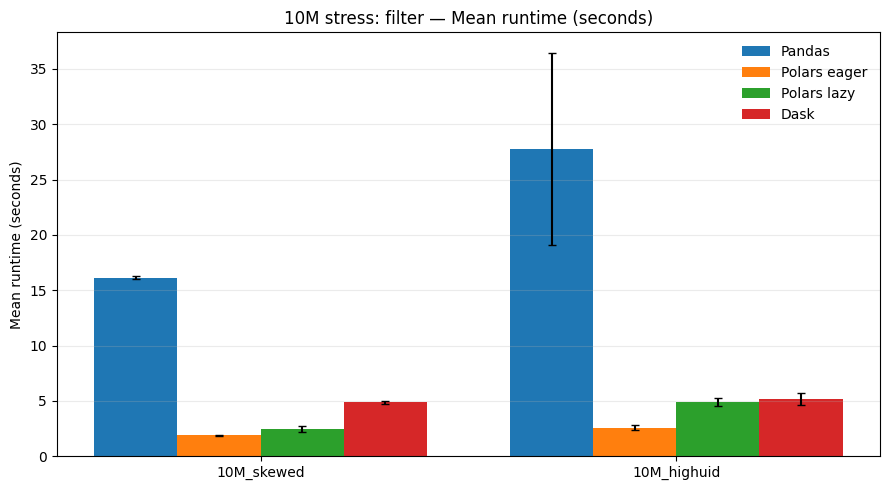

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress10m_runtime_filter.png


In [25]:
plot_stress10m_single(
    workload="filter",
    metric="time_mean_s",
    ylabel="Mean runtime (seconds)",
    filename_prefix="stress10m_runtime",
)

### Filter runtime under 10M stress

Biểu đồ `filter` cho thấy các engine dựa trên Polars vẫn giữ lợi thế rõ rệt so với Pandas và Dask trong cả hai stress scenario `10M_skewed` và `10M_highuid`.

Ở `10M_skewed`, Polars eager là nhanh nhất, khoảng **1.89s**, tiếp theo là Polars lazy với **2.41s**. Dask mất khoảng **4.85s**, còn Pandas chậm hơn đáng kể với **16.11s**. Điều này cho thấy với workload scan/filter ở dữ liệu skewed, Polars xử lý hiệu quả hơn nhiều so với Pandas và Dask.

Ở `10M_highuid`, Polars eager tiếp tục nhanh nhất với khoảng **2.58s**. Polars lazy và Dask khá gần nhau, lần lượt khoảng **4.91s** và **5.20s**. Pandas vẫn chậm nhất với **27.78s** và có độ dao động lớn hơn nhiều, thể hiện qua error bar cao.

So sánh giữa hai stress scenario, `10M_highuid` làm runtime tăng đối với Pandas và cả hai biến thể Polars, trong khi Dask gần như chỉ tăng nhẹ. Điều này cho thấy high-cardinality user IDs có thể làm tăng chi phí filter/materialization hoặc overhead xử lý dữ liệu, nhưng mức độ ảnh hưởng khác nhau theo từng framework.

Nhìn chung, với workload `filter`, Polars eager là lựa chọn nhanh nhất trong cả hai stress setup, Polars lazy vẫn cạnh tranh tốt, Dask ổn định nhưng chậm hơn Polars, còn Pandas kém phù hợp hơn cho workload stress ở quy mô `10M`.

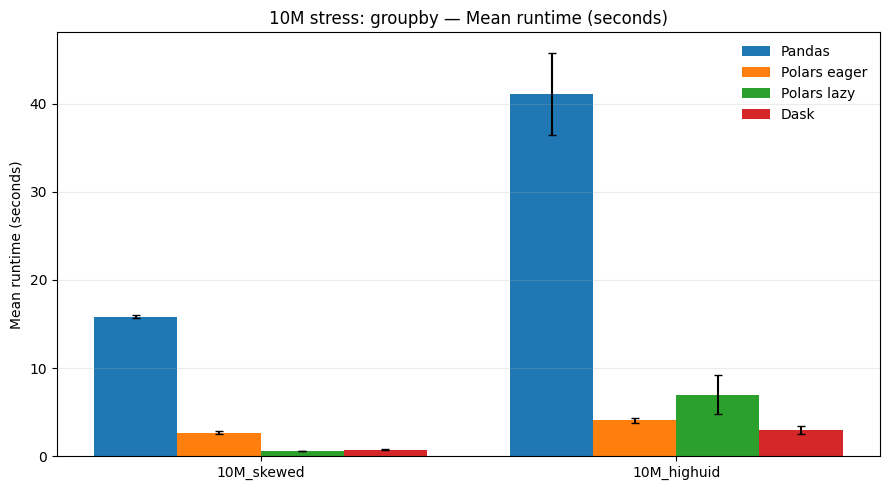

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress10m_runtime_groupby.png


In [27]:
plot_stress10m_single(
    workload="groupby",
    metric="time_mean_s",
    ylabel="Mean runtime (seconds)",
    filename_prefix="stress10m_runtime",
)

### Groupby runtime under 10M stress

Biểu đồ `groupby` cho thấy workload aggregation rất nhạy với data shape. Hai stress scenario `10M_skewed` và `10M_highuid` tạo ra hai hành vi gần như đối lập.

Ở `10M_skewed`, `groupby` trở nên rất nhẹ đối với Polars lazy và Dask. Polars lazy chỉ mất khoảng **0.62s**, còn Dask khoảng **0.71s**. Điều này cho thấy skew có thể làm giảm số nhóm hiệu dụng hoặc làm output aggregation nhỏ hơn, khiến chi phí hash aggregation thấp hơn nhiều. Polars eager cũng chạy nhanh, khoảng **2.67s**, trong khi Pandas chậm hơn rõ rệt với khoảng **15.83s**.

Ở `10M_highuid`, runtime tăng mạnh với hầu hết framework. Pandas bị ảnh hưởng nặng nhất, tăng lên khoảng **41.13s**. Polars lazy cũng tăng đáng kể lên **6.97s**, phản ánh chi phí cao hơn khi số lượng key/user ID unique lớn hơn. Dask đạt khoảng **2.98s**, nhanh nhất trong scenario này, còn Polars eager đứng sau với khoảng **4.07s**.

So sánh hai stress scenario, `10M_skewed` làm `groupby` dễ hơn đối với các engine có khả năng aggregation tốt, trong khi `10M_highuid` làm workload khó hơn vì số nhóm lớn hơn, intermediate state nhiều hơn và chi phí hash aggregation cao hơn. Vì vậy, kết quả `groupby` không nên được đọc đơn giản theo số rows, mà phải gắn với cardinality và phân phối của key.

Nhìn chung, Polars lazy và Dask thể hiện rất tốt ở skewed setup, nhưng ở high-cardinality setup, Dask có lợi thế runtime rõ hơn. Pandas là framework kém phù hợp nhất cho `groupby` trong cả hai stress scenario, đặc biệt khi cardinality tăng cao.

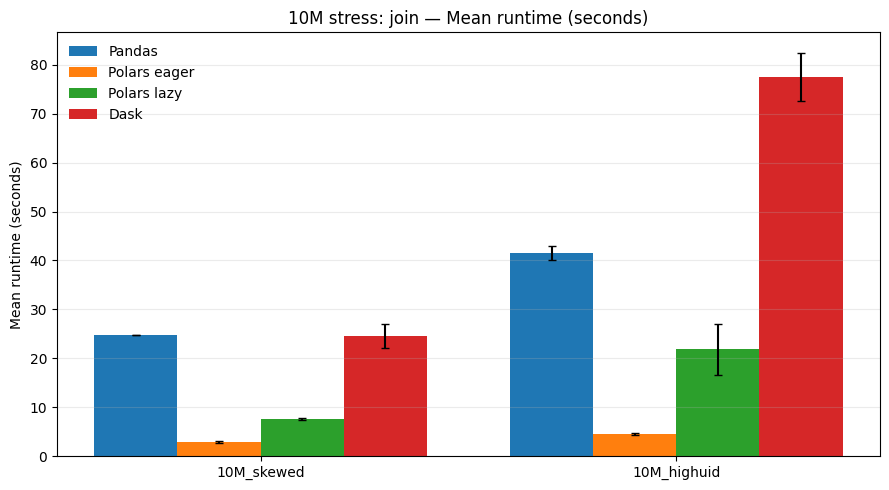

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress10m_runtime_join.png


In [26]:
plot_stress10m_single(
    workload="join",
    metric="time_mean_s",
    ylabel="Mean runtime (seconds)",
    filename_prefix="stress10m_runtime",
)

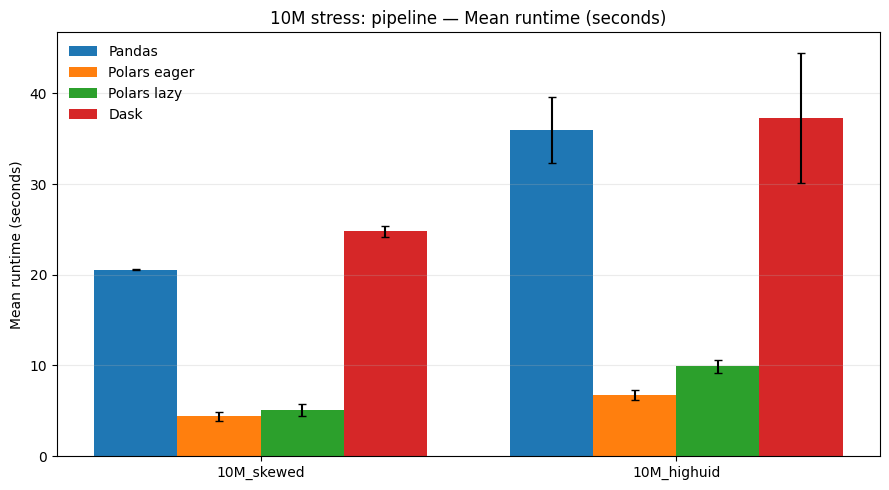

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress10m_runtime_pipeline.png


In [28]:
plot_stress10m_single(
    workload="pipeline",
    metric="time_mean_s",
    ylabel="Mean runtime (seconds)",
    filename_prefix="stress10m_runtime",
)

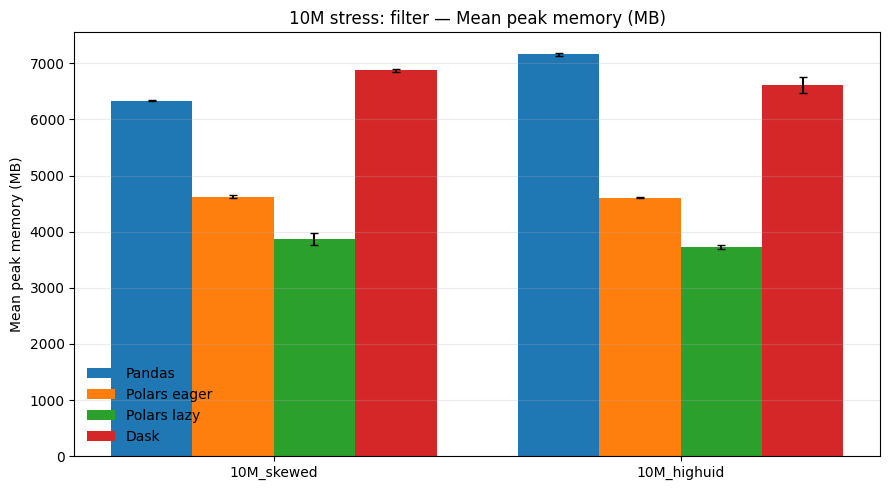

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress10m_memory_filter.png


In [29]:
plot_stress10m_single(
    workload="filter",
    metric="memory_mean_mb",
    ylabel="Mean peak memory (MB)",
    filename_prefix="stress10m_memory",
)

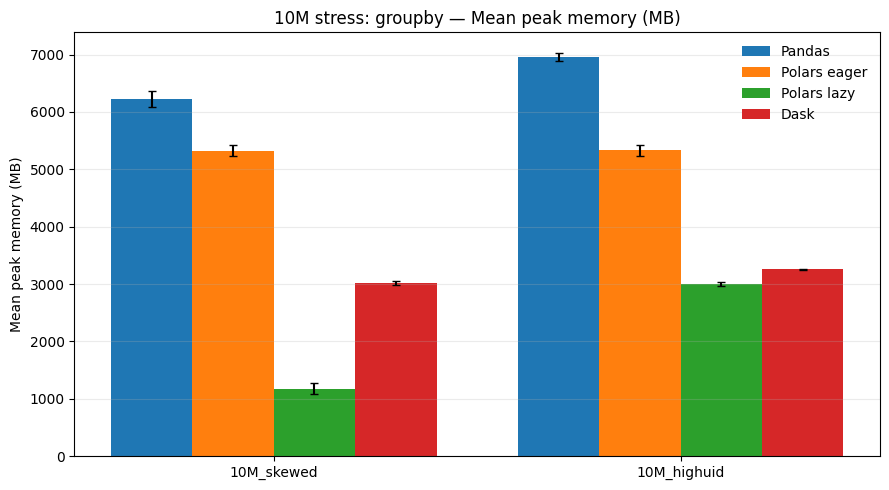

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress10m_memory_groupby.png


In [30]:
plot_stress10m_single(
    workload="groupby",
    metric="memory_mean_mb",
    ylabel="Mean peak memory (MB)",
    filename_prefix="stress10m_memory",
)

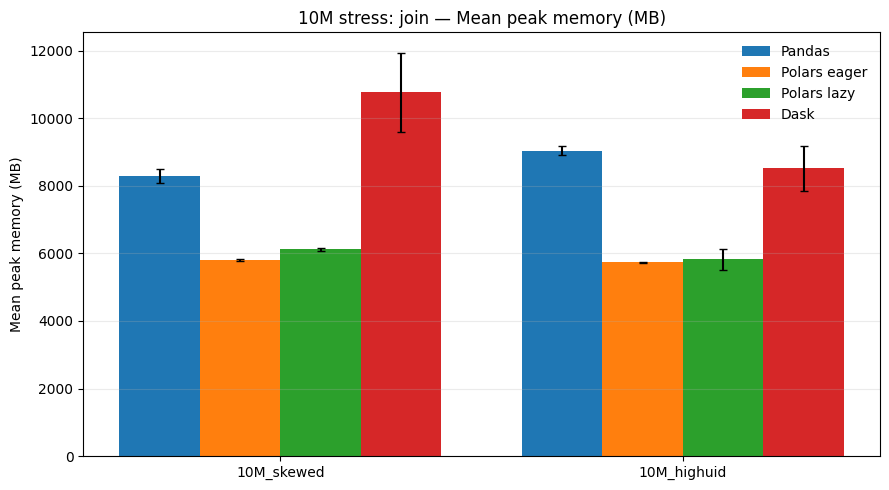

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress10m_memory_join.png


In [31]:
plot_stress10m_single(
    workload="join",
    metric="memory_mean_mb",
    ylabel="Mean peak memory (MB)",
    filename_prefix="stress10m_memory",
)

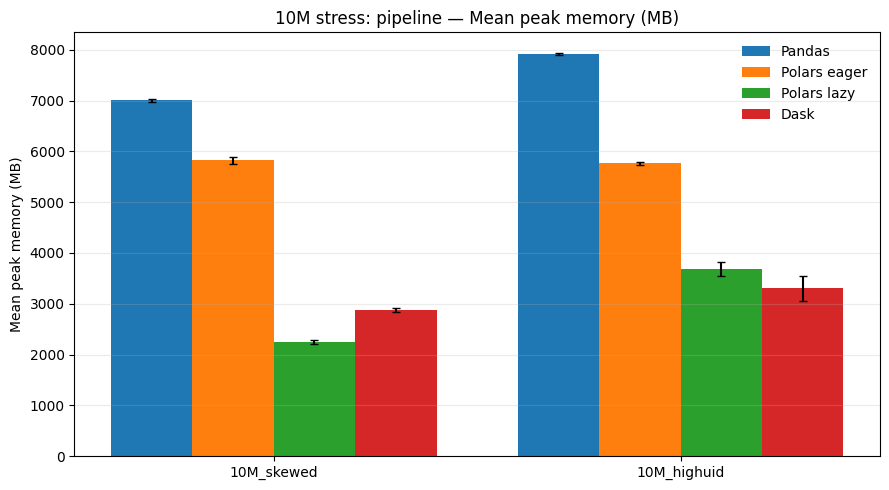

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress10m_memory_pipeline.png


In [32]:
plot_stress10m_single(
    workload="pipeline",
    metric="memory_mean_mb",
    ylabel="Mean peak memory (MB)",
    filename_prefix="stress10m_memory",
)

### What this means

`10M_skewed` và `10M_highuid` không chỉ kiểm tra tốc độ; chúng kiểm tra độ nhạy với phân phối dữ liệu. Nếu một framework nhanh trên real `10M` nhưng slowdown mạnh khi key bị skew hoặc cardinality tăng, điều đó cho thấy ranking trên dữ liệu bình thường không đủ để dự đoán stress behavior.

Vì cả hai stress case đều có cùng row count `10M`, so sánh trong từng framework/workload là hợp lệ hơn so với trộn trực tiếp với `100M`.

## 8. Stress Slowdown Relative to Real `10M`

Biểu đồ sau chuẩn hóa runtime theo mốc real `10M` của chính framework đó. Giá trị `1.0` nghĩa là stress case chạy ngang với real `10M`; lớn hơn `1.0` là chậm hơn; nhỏ hơn `1.0` là nhanh hơn.

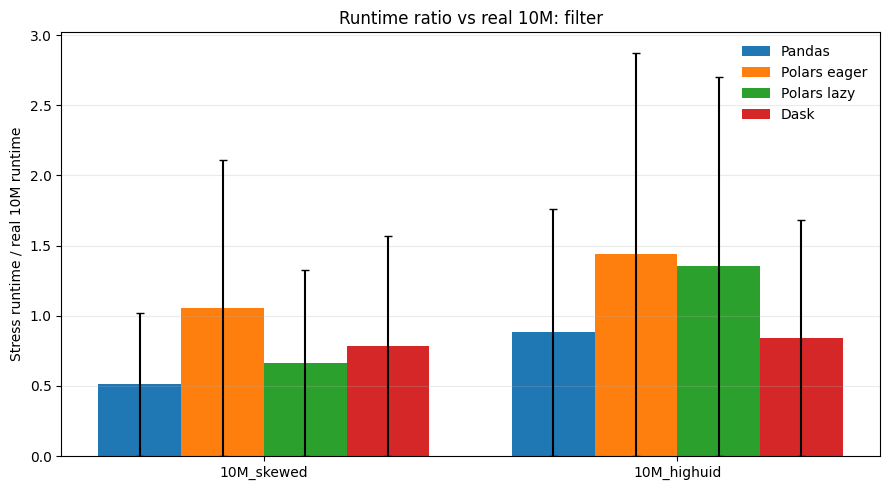

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress_ratio_vs_real_10m_filter.png


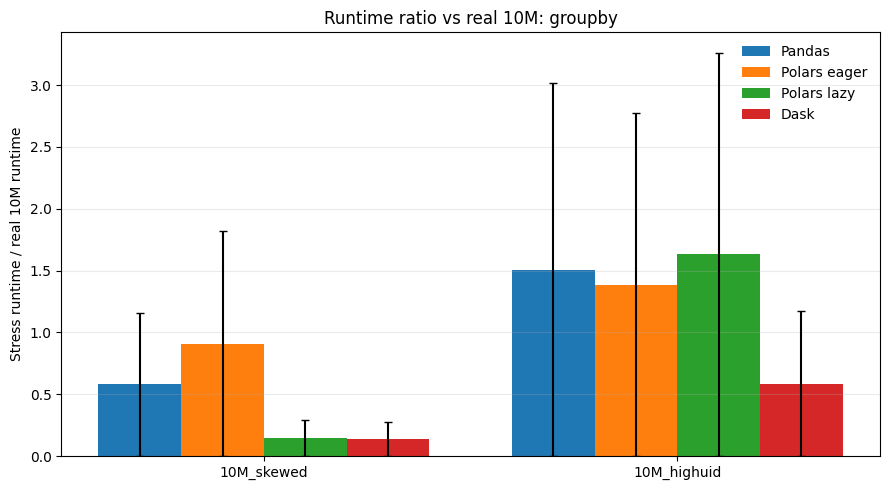

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress_ratio_vs_real_10m_groupby.png


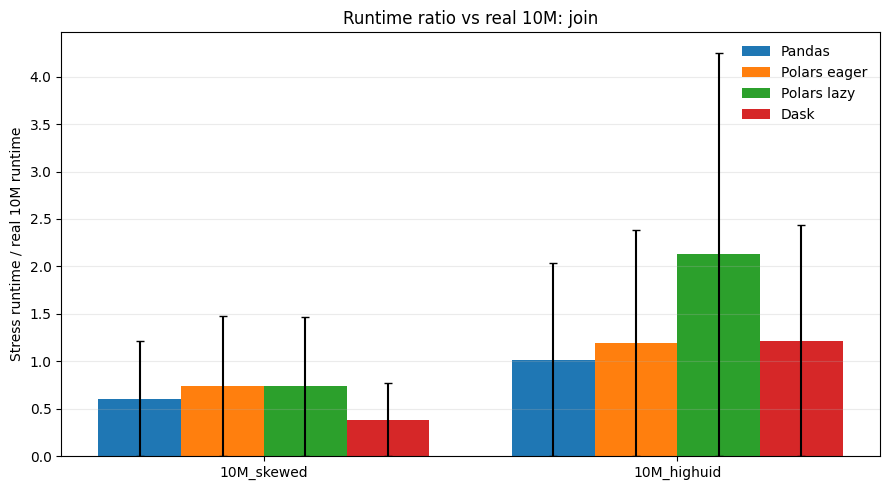

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress_ratio_vs_real_10m_join.png


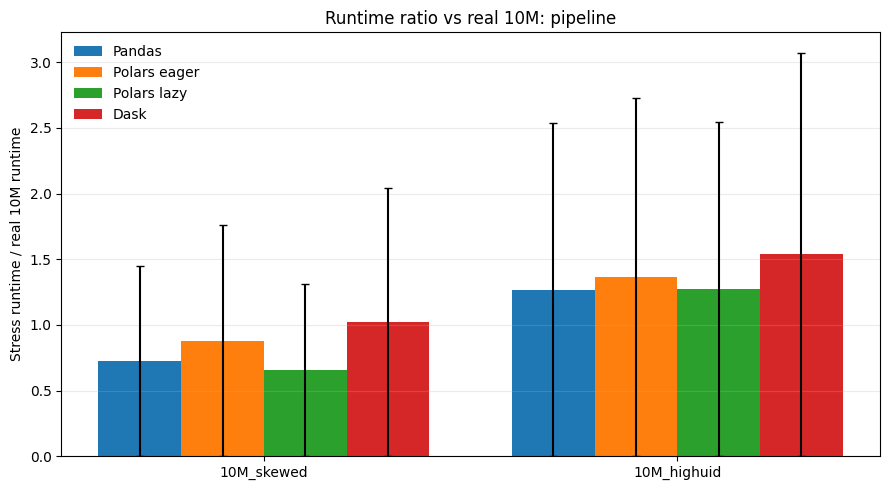

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\stress_ratio_vs_real_10m_pipeline.png


In [17]:
for workload in WORKLOAD_ORDER:
    subset = stress_vs_real_10m[stress_vs_real_10m["workload"] == workload].copy()
    if subset.empty:
        continue
    grouped_bar(
        subset,
        x_col="dataset_size",
        y_col="time_ratio_vs_real_10m",
        hue_col="framework",
        title=f"Runtime ratio vs real 10M: {workload}",
        ylabel="Stress runtime / real 10M runtime",
        filename=f"stress_ratio_vs_real_10m_{workload}.png",
        order=STRESS_ORDER,
        hue_order=FRAMEWORK_ORDER,
    )

In [18]:
# Compact ranking table: lower runtime ratio means less slowdown relative to the same framework's real 10M baseline.
ratio_rank = stress_vs_real_10m.copy()
ratio_rank["rank_within_stress_workload"] = ratio_rank.groupby(
    ["dataset_size", "workload"], observed=True
)["time_ratio_vs_real_10m"].rank(method="min")

ranking_display = ratio_rank[[
    "dataset_size", "workload", "framework", "time_ratio_vs_real_10m",
    "memory_ratio_vs_real_10m", "rank_within_stress_workload"
]].copy()
for col in ["time_ratio_vs_real_10m", "memory_ratio_vs_real_10m"]:
    ranking_display[col] = ranking_display[col].round(3)

display(ranking_display.sort_values(["dataset_size", "workload", "rank_within_stress_workload"]))

,dataset_size,workload,framework,time_ratio_vs_real_10m,memory_ratio_vs_real_10m,rank_within_stress_workload
28,10M_highuid,filter,dask,0.839,1.033,1.0
16,10M_highuid,filter,pandas,0.881,1.089,2.0
24,10M_highuid,filter,polars_lazy,1.352,1.097,3.0
20,10M_highuid,filter,polars_eager,1.438,1.042,4.0
29,10M_highuid,groupby,dask,0.586,0.827,1.0
21,10M_highuid,groupby,polars_eager,1.385,0.997,2.0
17,10M_highuid,groupby,pandas,1.508,1.093,3.0
25,10M_highuid,groupby,polars_lazy,1.631,0.609,4.0
18,10M_highuid,join,pandas,1.017,1.063,1.0
22,10M_highuid,join,polars_eager,1.192,1.017,2.0


### Interpretation rule

Ranking theo `time_ratio_vs_real_10m` trả lời câu hỏi “framework này bị stress làm chậm đi bao nhiêu so với chính nó?”. Ranking theo `time_mean_s` trả lời câu hỏi khác: “framework nào nhanh nhất tuyệt đối?”. Notebook này cần cả hai vì stress benchmark quan tâm đến robustness, không chỉ tốc độ thô.

## 9. Polars Lazy vs Eager Under Stress

Polars có hai execution mode trong các stress case `10M`: eager và lazy. Phần này chỉ là stress-specific summary để hỗ trợ notebook hiện tại; phân tích đầy đủ về lazy vs eager nên được tách sang notebook riêng theo benchmark design.

In [19]:
polars_modes = stress_10m[stress_10m["framework"].isin(["polars_eager", "polars_lazy"])].copy()
polars_pivot = polars_modes.pivot_table(
    index=["dataset_size", "workload"],
    columns="framework",
    values=["time_mean_s", "memory_mean_mb"],
    observed=True,
)
polars_pivot.columns = ["_".join(col).strip() for col in polars_pivot.columns.to_flat_index()]
polars_pivot = polars_pivot.reset_index()
polars_pivot["lazy_speedup_vs_eager"] = polars_pivot["time_mean_s_polars_eager"] / polars_pivot["time_mean_s_polars_lazy"]
polars_pivot["lazy_memory_ratio_vs_eager"] = polars_pivot["memory_mean_mb_polars_lazy"] / polars_pivot["memory_mean_mb_polars_eager"]

polars_display = polars_pivot.copy()
for col in polars_display.columns:
    if col not in ["dataset_size", "workload"]:
        polars_display[col] = polars_display[col].round(3)

display(polars_display.sort_values(["dataset_size", "workload"]))

,dataset_size,workload,memory_mean_mb_polars_eager,memory_mean_mb_polars_lazy,time_mean_s_polars_eager,time_mean_s_polars_lazy,lazy_speedup_vs_eager,lazy_memory_ratio_vs_eager
0,10M_highuid,filter,4608.863,3727.747,2.577,4.911,0.525,0.809
1,10M_highuid,groupby,5335.433,2997.750,4.071,6.969,0.584,0.562
2,10M_highuid,join,5734.213,5819.420,4.539,21.883,0.207,1.015
3,10M_highuid,pipeline,5760.893,3683.660,6.786,9.916,0.684,0.639
4,10M_skewed,filter,4625.123,3864.010,1.891,2.414,0.783,0.835
5,10M_skewed,groupby,5328.640,1176.987,2.674,0.624,4.287,0.221
6,10M_skewed,join,5793.983,6117.653,2.817,7.564,0.372,1.056
7,10M_skewed,pipeline,5822.367,2247.260,4.381,5.106,0.858,0.386


C:\Users\Duy\AppData\Local\Temp\ipykernel_13464\23289994.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_data["case"], rotation=45, ha="right")


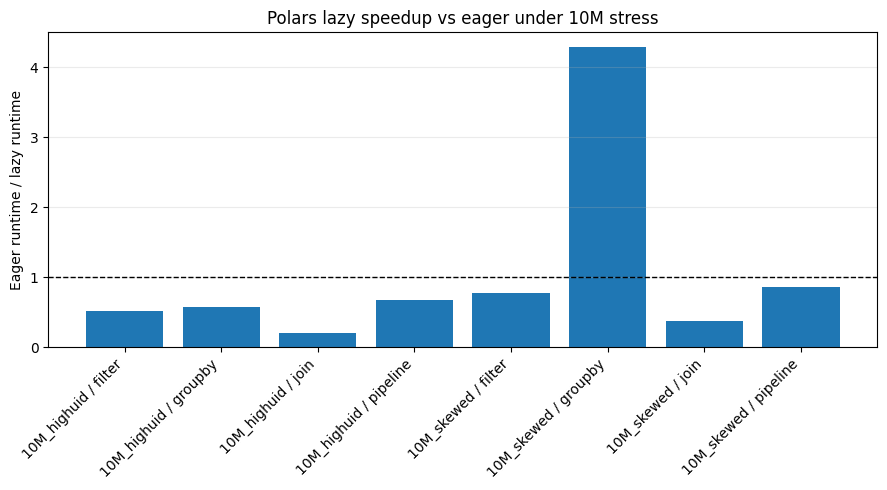

Saved: D:\Polar vs Dask\results\figures\notebook_04_synthetic_stress\polars_lazy_speedup_vs_eager_stress10m.png


In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = polars_pivot.copy()
plot_data["case"] = plot_data["dataset_size"].astype(str) + " / " + plot_data["workload"].astype(str)
ax.bar(plot_data["case"], plot_data["lazy_speedup_vs_eager"])
ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
ax.set_title("Polars lazy speedup vs eager under 10M stress")
ax.set_ylabel("Eager runtime / lazy runtime")
ax.set_xticklabels(plot_data["case"], rotation=45, ha="right")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
out = FIGURE_DIR / "polars_lazy_speedup_vs_eager_stress10m.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

### What this means

Polars lazy không nên được mô tả đơn giản là “luôn nhanh hơn”. Trong các stress case, lợi ích phụ thuộc workload: lazy có thể thắng khi optimizer giảm được work hoặc tận dụng execution plan tốt hơn, nhưng eager có thể rất cạnh tranh ở thao tác đơn giản hoặc khi overhead lazy không bù được.

Ở `100M`, kết luận lại khác: Polars eager không nằm trong phạm vi an toàn của máy, nên practical recommendation cho scale cực lớn là dùng Polars lazy/streaming-style execution hoặc Dask, không dùng eager materialization.

## 10. Failure and Scope Summary

Bảng dưới đây gom lại scope thực nghiệm để tránh diễn giải quá mức.

In [21]:
observed_scope = pd.DataFrame([
    {"scenario": "100M_real_like", "valid_frameworks": "polars_lazy, dask", "valid_workloads": "filter, groupby", "interpretation": "Large-row stress probe only."},
    {"scenario": "10M_skewed", "valid_frameworks": "pandas, polars_eager, polars_lazy, dask", "valid_workloads": "filter, groupby, join, pipeline", "interpretation": "Compare skew sensitivity within each framework and workload."},
    {"scenario": "10M_highuid", "valid_frameworks": "pandas, polars_eager, polars_lazy, dask", "valid_workloads": "filter, groupby, join, pipeline", "interpretation": "Compare cardinality pressure within each framework and workload."},
])

display(observed_scope)

actual_failures = df_raw[df_raw["status"] != "ok"].copy()
if len(actual_failures):
    actual_failure_taxonomy = (
        actual_failures
        .assign(
            scope_status="executed_failed",
            failure_class=lambda d: d["status"].fillna("unknown"),
            reason=lambda d: d["notes"].fillna("").replace("", "No reason recorded"),
        )
        .groupby(["stress_scenario", "framework", "workload", "scope_status", "failure_class", "reason"], observed=True)
        .size()
        .rename("n_runs")
        .reset_index()
    )
else:
    actual_failure_taxonomy = pd.DataFrame(columns=[
        "stress_scenario", "framework", "workload", "scope_status", "failure_class", "reason", "n_runs"
    ])

omitted_taxonomy = omitted_100m.rename(columns={
    "scenario": "stress_scenario",
})[["stress_scenario", "framework", "workload", "scope_status", "failure_class", "reason"]].copy()
omitted_taxonomy["n_runs"] = np.nan
omitted_taxonomy["taxonomy_type"] = "scope_or_aborted_note"
actual_failure_taxonomy["taxonomy_type"] = "actual_recorded_failure"

failure_taxonomy = pd.concat([actual_failure_taxonomy, omitted_taxonomy], ignore_index=True)
display(failure_taxonomy)

if len(actual_failure_taxonomy):
    print("Actual recorded failures exist in CSV results and should be analyzed separately from omitted-by-design rows.")
else:
    print("No actual failed rows are recorded in the CSV files. Scope exclusions and shutdown observations are documented separately above.")

,scenario,valid_frameworks,valid_workloads,interpretation
0,100M_real_like,"polars_lazy, dask","filter, groupby",Large-row stress probe only.
1,10M_skewed,"pandas, polars_eager, polars_lazy, dask","filter, groupby, join, pipeline",Compare skew sensitivity within each framework...
2,10M_highuid,"pandas, polars_eager, polars_lazy, dask","filter, groupby, join, pipeline",Compare cardinality pressure within each frame...


,stress_scenario,framework,workload,scope_status,failure_class,reason,n_runs,taxonomy_type
0,100M_real_like,pandas,filter/groupby/join/pipeline,omitted_by_design,practical_memory_envelope,Pandas 100M was excluded because it is outside...,NaN,scope_or_aborted_note
1,100M_real_like,polars_eager,filter/groupby/join/pipeline,attempted_aborted,system_shutdown,Polars eager 100M was attempted and caused the...,NaN,scope_or_aborted_note
2,100M_real_like,polars_lazy/dask,join,attempted_aborted,system_shutdown,100M join materialization/intermediate size wa...,NaN,scope_or_aborted_note
3,100M_real_like,polars_lazy/dask,pipeline,omitted_by_design,out_of_scope_due_to_join_pressure,Pipeline is excluded from 100M stress interpre...,NaN,scope_or_aborted_note


No actual failed rows are recorded in the CSV files. Scope exclusions and shutdown observations are documented separately above.


### Failure taxonomy interpretation

Bảng taxonomy tách hai loại khác nhau: `actual_recorded_failure` là failure có trong CSV result, còn `scope_or_aborted_note` là thông tin scope hoặc shutdown observation được ghi để bảo vệ methodology. Khi tính robustness ranking, chỉ nên dùng actual recorded failures và successful runs trong scope hợp lệ; omitted-by-design không phải là bằng chứng framework fail.

## 11. Report-ready Summary

Bảng cuối gom mỗi kết luận thành bốn phần: finding, evidence, caveat, và sentence có thể dùng trong final report.

In [22]:
report_ready_summary = pd.DataFrame([
    {
        "main_finding": "100M stress is feasible only for the scoped scan/aggregation workloads in this environment.",
        "evidence": "Polars lazy and Dask have successful `filter` and `groupby` runs at 100M.",
        "caveat": "Pandas, Polars eager, join, and pipeline are outside the reportable 100M matrix for this environment.",
        "report_ready_sentence": "The 100M synthetic stress test should be interpreted as a scoped large-row probe: Polars lazy and Dask completed filter/groupby, while other 100M combinations were excluded or aborted due to practical memory pressure.",
    },
    {
        "main_finding": "100M results should not be used as a scaling law against real 50M.",
        "evidence": "The notebook shows 100M beside real 1M/10M/50M only as a reference marker.",
        "caveat": "Synthetic and real datasets can differ in physical size, compression, cardinality, and text distribution.",
        "report_ready_sentence": "The 100M marker extends the visible scale range, but it does not define a real-data scaling law because dataset source and physical footprint are different.",
    },
    {
        "main_finding": "10M stress sensitivity is evaluated within the same framework and workload.",
        "evidence": "Slowdown ratios match `10M_skewed` and `10M_highuid` to real `10M` by framework/workload.",
        "caveat": "Ratios are not comparable if the matching real 10M baseline is missing.",
        "report_ready_sentence": "Skew and high-cardinality effects are measured as within-framework, same-workload ratios against the real 10M baseline.",
    },
    {
        "main_finding": "Omitted-by-design rows are not actual benchmark failures.",
        "evidence": "Failure taxonomy separates CSV-recorded failures from scope exclusions and shutdown observations.",
        "caveat": "Shutdown observations are still important practical limits, but they should not be counted as completed failed benchmark runs.",
        "report_ready_sentence": "The robustness analysis separates actual recorded failures from omitted-by-design combinations to avoid penalizing frameworks for experiments that were intentionally out of scope.",
    },
    {
        "main_finding": "Polars lazy/eager stress behavior is workload-dependent at 10M.",
        "evidence": "The notebook reports lazy speedup vs eager per stress case and workload.",
        "caveat": "Full lazy-vs-eager conclusions belong in the dedicated lazy/eager analysis notebook.",
        "report_ready_sentence": "Within the 10M stress cases, Polars lazy and eager should be compared per workload rather than collapsed into a single Polars result.",
    },
])

display(report_ready_summary)

,main_finding,evidence,caveat,report_ready_sentence
0,100M stress is feasible only for the scoped sc...,Polars lazy and Dask have successful `filter` ...,"Pandas, Polars eager, join, and pipeline are o...",The 100M synthetic stress test should be inter...
1,100M results should not be used as a scaling l...,The notebook shows 100M beside real 1M/10M/50M...,Synthetic and real datasets can differ in phys...,The 100M marker extends the visible scale rang...
2,10M stress sensitivity is evaluated within the...,Slowdown ratios match `10M_skewed` and `10M_hi...,Ratios are not comparable if the matching real...,Skew and high-cardinality effects are measured...
3,Omitted-by-design rows are not actual benchmar...,Failure taxonomy separates CSV-recorded failur...,Shutdown observations are still important prac...,The robustness analysis separates actual recor...
4,Polars lazy/eager stress behavior is workload-...,The notebook reports lazy speedup vs eager per...,Full lazy-vs-eager conclusions belong in the d...,"Within the 10M stress cases, Polars lazy and e..."


## 12. Export Tables

Các bảng chính được lưu vào `results/table/` để notebook report có thể đọc trực tiếp từ CSV thay vì phụ thuộc vào rendered notebook output. Cách export này mirror notebook `03_physical_scaling.ipynb`.

In [23]:
TABLE_DIR = PROJECT_ROOT / "results" / "table"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

export_tables = {
    "synthetic_stress_comparison_boundary.csv": comparison_boundary,
    "synthetic_stress_validation_requirements.csv": synthetic_validation_requirements,
    "synthetic_stress_run_count.csv": run_count,
    "synthetic_stress_completion_matrix.csv": stress_completion.reset_index(),
    "synthetic_stress_omitted_100m.csv": omitted_100m,
    "synthetic_stress_summary.csv": summary,
    "synthetic_stress_100m_summary.csv": stress_100m,
    "synthetic_stress_scale_compare_real_plus_100m.csv": scale_compare,
    "synthetic_stress_100m_vs_real_50m.csv": compare_100m_vs_50m,
    "synthetic_stress_10m_summary.csv": stress_10m,
    "synthetic_stress_vs_real_10m.csv": stress_vs_real_10m,
    "synthetic_stress_missing_baseline.csv": missing_baseline,
    "synthetic_stress_ratio_rank.csv": ratio_rank,
    "synthetic_stress_polars_lazy_vs_eager.csv": polars_pivot,
    "synthetic_stress_observed_scope.csv": observed_scope,
    "synthetic_stress_failure_taxonomy.csv": failure_taxonomy,
    "synthetic_stress_report_ready_summary.csv": report_ready_summary,
}

export_manifest = []
for filename, table in export_tables.items():
    path = TABLE_DIR / filename
    table.to_csv(path, index=False)
    export_manifest.append({
        "file": filename,
        "rows": len(table),
        "columns": len(table.columns),
        "path": str(path),
    })

export_manifest = pd.DataFrame(export_manifest).sort_values("file").reset_index(drop=True)
manifest_path = TABLE_DIR / "synthetic_stress_export_manifest.csv"
export_manifest.to_csv(manifest_path, index=False)

display(export_manifest)
print(f"Saved {len(export_manifest)} tables to {TABLE_DIR}")

,file,rows,columns,path
0,synthetic_stress_100m_summary.csv,4,17,D:\Polar vs Dask\results\table\synthetic_stres...
1,synthetic_stress_100m_vs_real_50m.csv,4,21,D:\Polar vs Dask\results\table\synthetic_stres...
2,synthetic_stress_10m_summary.csv,32,17,D:\Polar vs Dask\results\table\synthetic_stres...
3,synthetic_stress_comparison_boundary.csv,6,3,D:\Polar vs Dask\results\table\synthetic_stres...
4,synthetic_stress_completion_matrix.csv,10,6,D:\Polar vs Dask\results\table\synthetic_stres...
5,synthetic_stress_failure_taxonomy.csv,4,8,D:\Polar vs Dask\results\table\synthetic_stres...
6,synthetic_stress_missing_baseline.csv,0,5,D:\Polar vs Dask\results\table\synthetic_stres...
7,synthetic_stress_observed_scope.csv,3,4,D:\Polar vs Dask\results\table\synthetic_stres...
8,synthetic_stress_omitted_100m.csv,4,6,D:\Polar vs Dask\results\table\synthetic_stres...
9,synthetic_stress_polars_lazy_vs_eager.csv,8,8,D:\Polar vs Dask\results\table\synthetic_stres...


Saved 17 tables to D:\Polar vs Dask\results\table
